In [1]:
import mlflow

In [2]:
# Define the MLflow storage path
mlflow_storage_path = "/Users/dianaterraza/Desktop/corporacion_favorita/mlflow_results"

# Set MLflow to log to the directory
mlflow.set_tracking_uri(f"file:{mlflow_storage_path}")

In [3]:
# Set up experiment name
mlflow.set_experiment("Demand Forecast Experiment")

<Experiment: artifact_location='file:///Users/dianaterraza/Desktop/corporacion_favorita/mlflow_results/832087414255040998', creation_time=1737802939564, experiment_id='832087414255040998', last_update_time=1737802939564, lifecycle_stage='active', name='Demand Forecast Experiment', tags={}>

## Start MLFlow UI

In [4]:
from pyngrok import ngrok, conf
import getpass
import subprocess

In [5]:
subprocess.Popen(["mlflow", "ui", "--backend-store-uri", mlflow_storage_path])

<Popen: returncode: None args: ['mlflow', 'ui', '--backend-store-uri', '/Use...>

# Import all libraries we will need for the modeling and evaluation

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import mlflow.pyfunc
import mlflow.models
from mlflow.models.signature import infer_signature
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

[2025-01-25 12:18:44 +0100] [8011] [INFO] Starting gunicorn 23.0.0
[2025-01-25 12:18:44 +0100] [8011] [INFO] Listening at: http://127.0.0.1:5000 (8011)
[2025-01-25 12:18:44 +0100] [8011] [INFO] Using worker: sync
[2025-01-25 12:18:44 +0100] [8012] [INFO] Booting worker with pid: 8012
[2025-01-25 12:18:44 +0100] [8013] [INFO] Booting worker with pid: 8013
[2025-01-25 12:18:44 +0100] [8014] [INFO] Booting worker with pid: 8014
[2025-01-25 12:18:44 +0100] [8015] [INFO] Booting worker with pid: 8015


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Ngrok is locally running aplication at http://127.0.0.1:5000 (ahí es donde esta my ngrok)

# Read the files with pandas

In [7]:
# Load the CSV files into pandas DataFrames
df_stores = pd.read_csv('/Users/dianaterraza/Desktop/Data/stores.csv')
df_items = pd.read_csv('/Users/dianaterraza/Desktop/Data/items.csv')
df_transactions = pd.read_csv('/Users/dianaterraza/Desktop/Data/transactions.csv')
df_oil = pd.read_csv('/Users/dianaterraza/Desktop/Data/oil.csv')
df_holidays_events = pd.read_csv('/Users/dianaterraza/Desktop/Data/holidays_events.csv')
df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')
df_test = pd.read_csv('/Users/dianaterraza/Desktop/Data/test.csv')

[2025-01-25 12:12:41 +0100] [7715] [INFO] Starting gunicorn 23.0.0
[2025-01-25 12:12:41 +0100] [7715] [INFO] Listening at: http://127.0.0.1:5000 (7715)
[2025-01-25 12:12:41 +0100] [7715] [INFO] Using worker: sync
[2025-01-25 12:12:41 +0100] [7716] [INFO] Booting worker with pid: 7716
[2025-01-25 12:12:41 +0100] [7717] [INFO] Booting worker with pid: 7717
[2025-01-25 12:12:41 +0100] [7718] [INFO] Booting worker with pid: 7718
[2025-01-25 12:12:41 +0100] [7719] [INFO] Booting worker with pid: 7719
/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_7705/2255240867.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')


## Read the sales history for a few items in the state 'Guayas'

In [8]:
# Select list of stores located in the 'Guayas' region
store_ids = df_stores[df_stores['state'] == 'Guayas']['store_nbr'].unique()

#Select the same items as for "Classical methods":
item_ids = [96995,99197,2134058,103501,103520]

# Define the date range for January-March 2014
start_date = '2014-01-01'
end_date = '2014-03-31'

# Initialize an empty list to hold filtered chunks
filtered_chunks = []

# Define the chunk size (number of rows per chunk)
chunk_size = 10 ** 6  # Adjust based on your system's memory capacity

# Read the CSV file in chunks
for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):
    # Filter the chunk for the desired store IDs and date range
    chunk_filtered = chunk[(chunk['store_nbr'].isin(store_ids)) &
                            (chunk['date'] >= start_date) &
                            (chunk['date'] <= end_date)]

    # Append the filtered chunk to the list
    filtered_chunks.append(chunk_filtered)

    # Optional: Delete the chunk to free up memory
    del chunk

# Concatenate all filtered chunks into a single DataFrame
df_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Clean up to free memory
del filtered_chunks

# Group by date and aggregate sales
df_filtered = df_filtered.groupby(['store_nbr','item_nbr','date']).sum()['unit_sales'].reset_index()

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_7705/3804623635.py:18: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):


In [9]:
df_filtered.shape

(996117, 4)

## Feature engineering

## Fill out missing dates with 0 sales

In [10]:
import pandas as pd

# Convert 'date' column to datetime format
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Create an empty DataFrame to store the final result
df_filled = pd.DataFrame()

# Iterate through each store and item combination
for (store, item), group in df_filtered.groupby(['store_nbr', 'item_nbr']):
    # Get the minimum and maximum dates in the dataset to create a full date range
    min_date = group['date'].min()
    max_date = group['date'].max()
    #print(min_date.date(), max_date.date())

    # Create a full date range covering all days between the min and max dates
    full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

    # Set 'date' as index and sort by date
    group.set_index('date', inplace=True)
    group = group.sort_index()

    # Reindex to fill missing dates with 0 sales
    group = group.reindex(full_date_range, fill_value=0)

    # Keep track of the store and item number for each row
    group['store_nbr'] = store
    group['item_nbr'] = item

    # Ensure that missing sales values are filled with 0
    group['unit_sales'] = group['unit_sales'].fillna(0)

    # Append the group to the final DataFrame
    df_filled = pd.concat([df_filled, group])

# Reset the index to get 'date' back as a column
df_filled.reset_index(inplace=True)
df_filled.rename(columns={'index': 'date'}, inplace=True)

## Add more time-based features

In [11]:
df_filled['month'] = df_filled['date'].dt.month
df_filled['day'] = df_filled['date'].dt.day
df_filled['weekofyear'] = df_filled['date'].dt.isocalendar().week
df_filled['dayofweek'] = df_filled['date'].dt.dayofweek
df_filled['rolling_mean'] = df_filled['unit_sales'].rolling(window=7).mean()
df_filled['rolling_std'] = df_filled['unit_sales'].rolling(window=7).std()


# Create lag features (e.g., sales from the previous day, previous week)
df_filled['lag_1'] = df_filled['unit_sales'].shift(1)
df_filled['lag_7'] = df_filled['unit_sales'].shift(7)
df_filled['lag_30'] = df_filled['unit_sales'].shift(30)

# Drop any rows with NaN values after creating lag features
df_filled.dropna(inplace=True)

# Add features related to stores and items

In [12]:
# Merge df_filtered with df_store and df_item on store_nbr and item_nbr, respectively
df_filled = df_filled.merge(df_stores, on='store_nbr', how='left').merge(df_items, on='item_nbr', how='left')

from sklearn.preprocessing import LabelEncoder
# Apply label encoding to each categorical column
le = LabelEncoder()
for col in ['city', 'state', 'type', 'family', 'class']:
    df_filled[col] = le.fit_transform(df_filled[col])

df_filled = df_filled.sort_values(by=['store_nbr', 'item_nbr', 'date'])

# Split in test and train datasets

In [13]:
split_date = '2014-03-01'
train = df_filled[df_filled['date'] < split_date]
test = df_filled[df_filled['date'] >= split_date]
print("Train dataframe shape:",train.shape)
print("Test dataframe shape:",test.shape)

Train dataframe shape: (986875, 20)
Test dataframe shape: (514720, 20)


# ML model with XGBoost

In [14]:
# Define target variable (unit_sales) and features
X_train = train.drop('unit_sales', axis=1)
X_train = X_train.drop('date', axis=1)
y_train = train['unit_sales']

X_test = test.drop('unit_sales', axis=1)
X_test = X_test.drop('date', axis=1)
y_test = test['unit_sales']

In [15]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, learning_rate=0.1, enable_categorical=True)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

/Users/dianaterraza/Desktop/Notebooks_nuevos/time/lib/python3.11/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

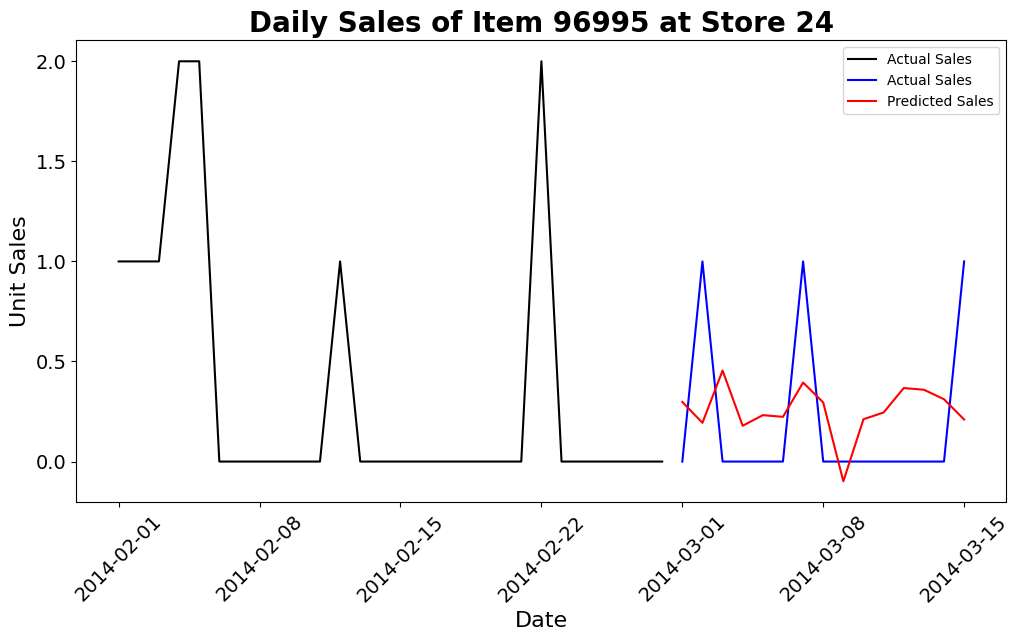

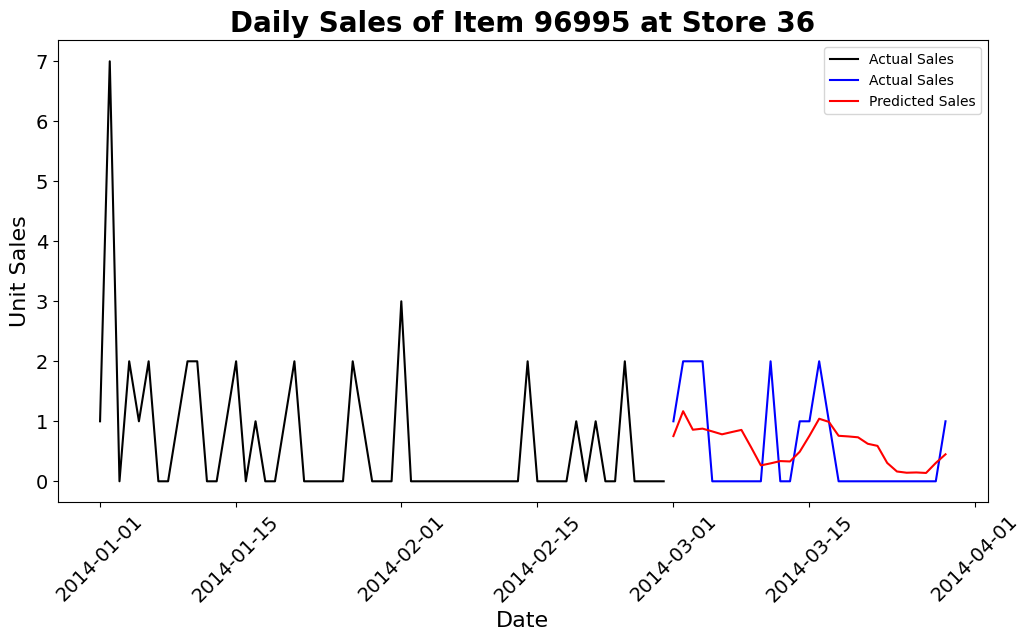

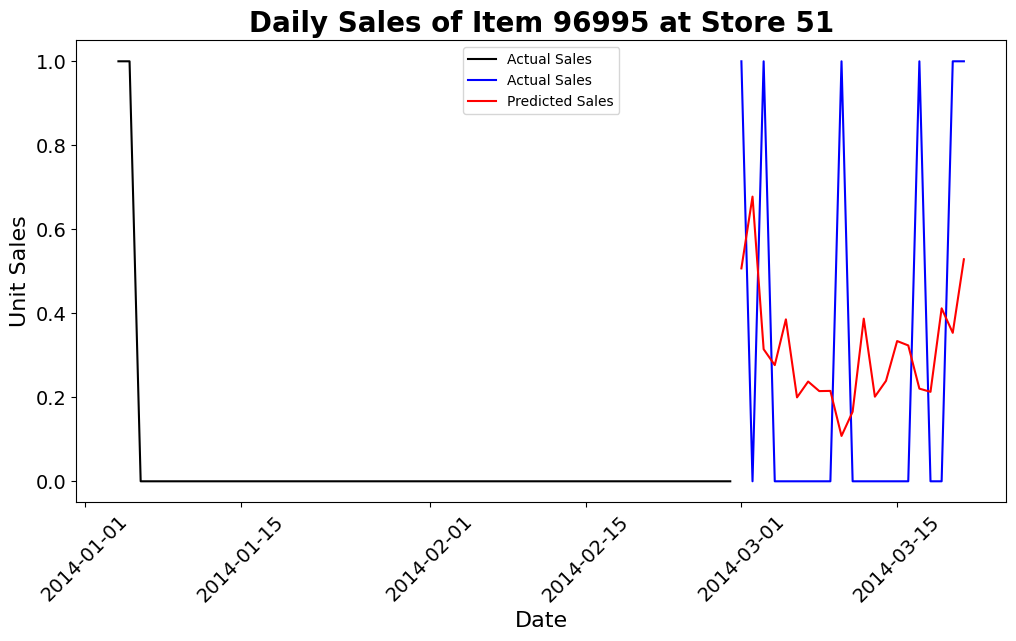

In [16]:
# Calculate metrics values and Plot the actual vs predicted values
rmad_values = []
bias_values = []
rmse_values = []
plot_paths = []
plot_count  = 0
for (item_nbr, store_nbr), group in df_filled.groupby(['item_nbr', 'store_nbr']):
  #group = group.groupby(['date']).sum()['unit_sales'].reset_index()
  test_series = group[group['date'] >= split_date]
  if(len(test_series)>10):
    X_test = test_series.drop('unit_sales', axis=1)
    X_test = X_test.drop('date', axis=1)
    y_test = test_series['unit_sales']
    # Make predictions on the test set
    y_pred = xgboost_model.predict(X_test)

    if plot_count<3:
      train_series = group[group['date'] < split_date]
      plt.figure(figsize=(12, 6))
      plt.plot(train_series['date'], train_series['unit_sales'].values, label='Actual Sales', color='black')
      plt.plot(test_series['date'], y_test.values, label='Actual Sales', color='blue')
      plt.plot(test_series['date'], y_pred, label='Predicted Sales', color='red')
      plt.title(f'Daily Sales of Item {item_nbr} at Store {store_nbr}', fontsize=20, fontweight='bold')
      plt.xlabel('Date', fontsize=16)
      plt.ylabel('Unit Sales', fontsize=16)
      plt.xticks(fontsize=14, rotation=45)
      plt.yticks(fontsize=14)
      file_path = f'XGBoost_forecast_store_{store_nbr}_item_{item_nbr}.png'
      plt.legend()
      plt.savefig(file_path)  # Saves the plot as a PNG file
      plt.show()
      plot_paths.append(file_path)
      plot_count = plot_count + 1

    #Calculate metric values for XGBoost model
    # Bias calculation: mean of the residuals (y_pred - y_test)
    bias = np.mean(y_pred - y_test)
    bias_values.append(bias)
    # Root Mean Absolute Deviation (RMAD)
    rmad = np.mean(np.abs(y_pred - y_test))
    rmad_values.append(rmad)
    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_values.append(rmse)

## Log metrics for XGBoost model in MLFlow

In [17]:
import mlflow.xgboost
with mlflow.start_run(run_name="XGBoost_store_item_features_run"):
    run_id = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id}")
    mlflow.log_param("objective", "reg:squarederror") #value we used above
    mlflow.log_param("n_estimators", 100) #value we used above
    mlflow.log_param("max_depth", 5) #value we used above
    mlflow.log_param("learning_rate", 0.1) #value we used above
    mlflow.log_metric("rMAD", sum(rmad_values)/len(rmad_values)) #average rMAD
    mlflow.log_metric("Bias", sum(bias_values)/len(bias_values)) #average Bias
    mlflow.log_metric("RMSE", sum(rmse_values)/len(rmse_values)) #average RMSE
    for plot_path in plot_paths:
      mlflow.log_artifact(plot_path, artifact_path="plots")
    # Log the XGBoost model
    ## Example data (replace with a sample from your dataset)
    #input_example = X_train[:5]
    # Infer signature from input and output data
    signature = infer_signature(X_train, xgboost_model.predict(X_train))
    #print(signature)
    #mlflow.sklearn.log_model(xgboost_model, "xgboost_model",
    #                         signature=signature)
    mlflow.xgboost.log_model(xgboost_model, "xgboost_model",
                             signature=signature)
    # Optionally log parameters, metrics, etc.
    mlflow.log_params(xgboost_model.get_params())
    mlflow.log_metric("train_score", xgboost_model.score(X_train, y_train))

Run ID: e9c259ecf47a4f5aaaa2aa37c4168adc


/Users/dianaterraza/Desktop/Notebooks_nuevos/time/lib/python3.11/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/dianaterraza/Desktop/Notebooks_nuevos/time/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [12:10:44] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1374: Saving model in 

### Hyperparameter Tuning Aproach:

* 1. Data Preparation:
Aggregate sales data by time and store, adding features like rolling averages, lagged sales, holidays, and oil prices.

* 2. Train-Test Split
Use historical data to create training (earlier dates) and test sets (later dates).

* 3. Cross-Validation (CV)
Use time series split CV for sequential validation.

* 4. Hyperparameter Search
Employ grid search or randomized search on critical parameters, using evaluation metrics like RMSE or MAE to measure accuracy.

In [19]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

# Prepare data with lagged features and rolling statistics

xgb = XGBRegressor(objective='reg:squarederror')

# Define the parameter grid
param_grid = {
    'eta': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'n_estimators': [100, 200, 300]
}

# Time series split for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Randomized search with cross-validation
random_search = RandomizedSearchCV(estimator=xgb,
																	 param_distributions=param_grid, 
                                   cv=tscv,
                                   n_iter=10,
                                   scoring='neg_mean_squared_error')

# Fit the model and search for the best hyperparameters
random_search.fit(X_train, y_train)

# Get best hyperparameters
best_params = random_search.best_params_
print("Best Parameters for XGBoost:", best_params)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

### Pickle:
"This is to deploy my application with the best-performing model."

In [19]:
logged_model = 'runs:/bd2b7dcf9f344798868816726faf2d69/xgboost_model' # this is the code of my model

# Load model as a generic PyFuncModel.
#loaded_model = mlflow.pyfunc.load_model(logged_model)
#input_schema = loaded_model.metadata.get_input_schema()
#print(input_schema)

# Load model as xgboost model
loaded_model = mlflow.xgboost.load_model(logged_model)
print("=== Model type",type(loaded_model))

=== Model type <class 'xgboost.sklearn.XGBRegressor'>
